In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [2]:
input_path = "data/all_models_30shuf_bp.csv"
output_path = os.path.splitext(input_path)[0]
if not os.path.exists(output_path):
	os.makedirs(output_path)
data = pd.read_csv(input_path)
all_experiments = pd.read_csv("data/experiments_list.txt", header=None, names=["model_name","pretrain_task"])
data = data.merge(all_experiments, on="model_name", how="left")
data.head()

,feature_class,model_name,pct_1,pct_0,baseline_pct_1_mean,baseline_pct_1_std,observed_baseline_ratio,predictions_sum,total_bp,pretrain_task
0,Alu,CADUCEUS-PH-512kb,0.857060,0.142940,0.577926,0.001760,1.482994,111375.0,129950,MLM-1bp
1,CR1,CADUCEUS-PH-512kb,0.510731,0.489269,0.577864,0.001964,0.883826,35052.0,68631,MLM-1bp
2,ERV1,CADUCEUS-PH-512kb,0.648134,0.351866,0.577893,0.000722,1.121548,406242.0,626787,MLM-1bp
3,ERVK,CADUCEUS-PH-512kb,0.469840,0.530160,0.577779,0.005087,0.813182,4689.0,9980,MLM-1bp
4,ERVL,CADUCEUS-PH-512kb,0.657921,0.342079,0.577984,0.000608,1.138304,370747.0,563513,MLM-1bp


In [3]:
data.query("feature_class != 'simpleRepeat'", inplace=True) # remove simple repeats: we have them twise, once from nested repeats and once from the dedicated file

In [4]:
# Compute the mean pct_1 per feature_class (across all models)
mean_pct1 = data.groupby("feature_class")["pct_1"].mean()
# Create an ordering of feature_class by descending mean pct_1
ordered_feature_classes = mean_pct1.sort_values(ascending=False).index.tolist()

# Get unique pretrain_task values
pretrain_tasks = sorted(data["pretrain_task"].dropna().unique())
n_tasks = len(pretrain_tasks)

# Create subplots
sns.set_context("notebook", font_scale=1.13)  # font_scale ~13pt for default context
sns.set_style("whitegrid")
fig, axes = plt.subplots(n_tasks, 1, figsize=(10, 10 * n_tasks), sharey=True)

# If only one subplot, axes won't be an array
if n_tasks == 1:
	axes = [axes]

for idx, pretrain_task in enumerate(pretrain_tasks):
	# Filter data for this pretrain_task
	task_data = data[data["pretrain_task"] == pretrain_task]

	# drop all checkpoints of the same model
	task_data["model_family"] = task_data["model_name"].apply(lambda x: "-".join(x.split("-")[:2]) if x.count("-")>=2 else x)
	task_data["model_epoch"] = task_data["model_name"].apply(lambda x: int(x.split("-ba")[-1]) if x.find("-ba")>-1 else 0)
	task_data.sort_values(by=["model_family", "model_epoch", "feature_class"], inplace=True, ascending=False)
	task_data.drop_duplicates(subset=["model_family",  "feature_class"], inplace=True, keep="first")

	# Calculate mean (1 - pct_1) for each model and sort models by this value (highest first)
	task_data["one_minus_pct1"] = 1 - task_data["pct_1"]
	model_ordering = task_data.groupby("model_name")["one_minus_pct1"].mean().sort_values(ascending=False).index.tolist()

	ax = axes[idx]
	sns.barplot(
		data=task_data,
		x="feature_class",
		y="pct_1",
		hue="model_name",
		order=ordered_feature_classes,
		hue_order=model_ordering,
		ax=ax
	)
	ax.set_xlabel("Feature type", fontsize=13)
	if idx == 0:
		ax.set_ylabel("Percentage of True base Predictions", fontsize=13)
	ax.set_title(f"Model base-pair accuracy by Feature Class\n({pretrain_task})", fontsize=13)
	ax.tick_params(axis='both', labelsize=13)
	ax.legend(title="Model Name", fontsize=13, title_fontsize=13)
	ax.tick_params(axis='x', rotation=45)
	ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(os.path.join(output_path, "MLM_acc_by_feature.png"), dpi=300, bbox_inches='tight')
plt.close(fig)

/tmp/ipykernel_1061640/3689601542.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_data["model_family"] = task_data["model_name"].apply(lambda x: "-".join(x.split("-")[:2]) if x.count("-")>=2 else x)
/tmp/ipykernel_1061640/3689601542.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_data["model_epoch"] = task_data["model_name"].apply(lambda x: int(x.split("-ba")[-1]) if x.find("-ba")>-1 else 0)
/tmp/ipykernel_1061640/3689601542.py:26: SettingWithCopyWarning: 
A value is trying to be set on 

In [5]:
# Get unique pretrain_task values
pretrain_tasks = ["modgena-base","modgena-large","modgena-xlarge"]
n_tasks = len(pretrain_tasks)

# Create subplots
sns.set_context("notebook", font_scale=1.13)  # font_scale ~13pt for default context
sns.set_style("whitegrid")
fig, axes = plt.subplots(n_tasks, 1, figsize=(10, 10 * n_tasks), sharey=True)

# If only one subplot, axes won't be an array
if n_tasks == 1:
	axes = [axes]


for idx, pretrain_task in enumerate(pretrain_tasks):
	# Filter data for this pretrain_task
	task_data = data[data["model_name"].str.contains(pretrain_task)]

	# Calculate mean (1 - pct_1) for each model and sort models by this value (highest first)
	task_data["one_minus_pct1"] = 1 - task_data["pct_1"]
	model_ordering = task_data.groupby("model_name")["one_minus_pct1"].mean().sort_values(ascending=False).index.tolist()

	ax = axes[idx]
	sns.barplot(
		data=task_data,
		x="feature_class",
		y="pct_1",
		hue="model_name",
		order=ordered_feature_classes,
		hue_order=model_ordering,
		ax=ax
	)
	ax.set_xlabel("Feature type", fontsize=13)
	if idx == 0:
		ax.set_ylabel("Percentage of True base Predictions", fontsize=13)
	ax.set_title(f"Model base-pair accuracy by Feature Class\n({pretrain_task})", fontsize=13)
	ax.tick_params(axis='both', labelsize=13)
	ax.legend(title="Model Name", fontsize=13, title_fontsize=13)
	ax.tick_params(axis='x', rotation=45)
	ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(output_path, "MLM_acc_by_pretrain_epoch.png"), dpi=300, bbox_inches='tight')
# plt.show()
plt.close(fig)

/tmp/ipykernel_1061640/761903574.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_data["one_minus_pct1"] = 1 - task_data["pct_1"]
/tmp/ipykernel_1061640/761903574.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1061640/761903574.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_data["one_minus_pct1"] = 1 - task_data["pct_1"

In [6]:
# Log2-transform the observed_baseline_ratio
data["log2_obs_baseline_ratio"] = np.log2(data["observed_baseline_ratio"])

# Compute the mean of the log2 observed_baseline_ratio per feature_class (across all models)
mean_log2_obs_baseline_ratio = data.groupby("feature_class")["log2_obs_baseline_ratio"].mean()
# Create an ordering of feature_class by descending mean log2 observed_baseline_ratio
ordered_feature_classes_log2_obs_baseline = mean_log2_obs_baseline_ratio.sort_values(ascending=False).index.tolist()

# Get unique pretrain_task values
pretrain_tasks = sorted(data["pretrain_task"].dropna().unique())
n_tasks = len(pretrain_tasks)

# Create subplots
sns.set_context("notebook", font_scale=1.13)
sns.set_style("whitegrid")
fig, axes = plt.subplots(n_tasks, 1, figsize=(10, 10 * n_tasks), sharey=True)

# If only one subplot, axes won't be an array
if n_tasks == 1:
	axes = [axes]

for idx, pretrain_task in enumerate(pretrain_tasks):
	# Filter data for this pretrain_task
	task_data = data[data["pretrain_task"] == pretrain_task].copy()

	# drop all checkpoints of the same model
	task_data["model_family"] = task_data["model_name"].apply(lambda x: "-".join(x.split("-")[:2]) if x.count("-")>=2 else x)
	task_data["model_epoch"] = task_data["model_name"].apply(lambda x: int(x.split("-ba")[-1]) if x.find("-ba")>-1 else 0)
	task_data.sort_values(by=["model_family", "model_epoch", "feature_class"], inplace=True, ascending=False)
	task_data.drop_duplicates(subset=["model_family",  "feature_class"], inplace=True, keep="first")

	# Calculate mean log2_obs_baseline_ratio for each model and sort models by this value (highest first)
	model_ordering = task_data.groupby("model_name")["log2_obs_baseline_ratio"].mean().sort_values(ascending=False).index.tolist()

	ax = axes[idx]
	sns.barplot(
		data=task_data,
		x="feature_class",
		y="log2_obs_baseline_ratio",
		hue="model_name",
		order=ordered_feature_classes_log2_obs_baseline,
		hue_order=model_ordering,
		ax=ax
	)
	ax.set_xlabel("Feature type", fontsize=13)
	if idx == 0:
		ax.set_ylabel("log2(Observed/Baseline Ratio)", fontsize=13)
	ax.set_title(f"log2(Observed-vs-Baseline Ratio) by Feature Class\n({pretrain_task})", fontsize=13)
	ax.tick_params(axis='both', labelsize=13)
	ax.legend(title="Model Name", fontsize=13, title_fontsize=13)
	ax.tick_params(axis='x', rotation=45)
	ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
	ax.grid(True, axis='x', alpha=0.3)

plt.savefig(os.path.join(output_path, "Obs-expected_MLM_acc_by_feature.png"), dpi=300, bbox_inches='tight')
# plt.tight_layout()
# plt.show()
plt.close(fig)


/tmp/ipykernel_1061640/3738784145.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1061640/3738784145.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1061640/3738784145.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1061640/3738784145.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


In [12]:
# for the feature exon show all models in one 
feature_exon_data = data[data["feature_class"] == "exon"].copy()

# Calculate mean (1 - pct_1) for each model and sort models by this value (highest first)
feature_exon_data["one_minus_pct1"] = 1 - feature_exon_data["pct_1"]
model_ordering = feature_exon_data.groupby("model_name")["one_minus_pct1"].mean().sort_values(ascending=False).index.tolist()

# Create a single plot showing all models for exon feature
sns.set_context("notebook", font_scale=1.13)
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, 1, figsize=(6, 10))

sns.barplot(
    data=feature_exon_data,
    x="model_name",
    y="pct_1",
    order=model_ordering,
    ax=ax
)
ax.set_xlabel("Model Name", fontsize=13)
ax.set_ylabel("Percentage of True base Predictions", fontsize=13)
ax.set_title("Model base-pair accuracy for Exon feature\n(All models)", fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.tick_params(axis='x', rotation=90)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
ax.grid(True, axis='both', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_path, "MLM_acc_exon_all_models.png"), dpi=300, bbox_inches='tight')
plt.close(fig)


/tmp/ipykernel_1061640/4276934253.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")


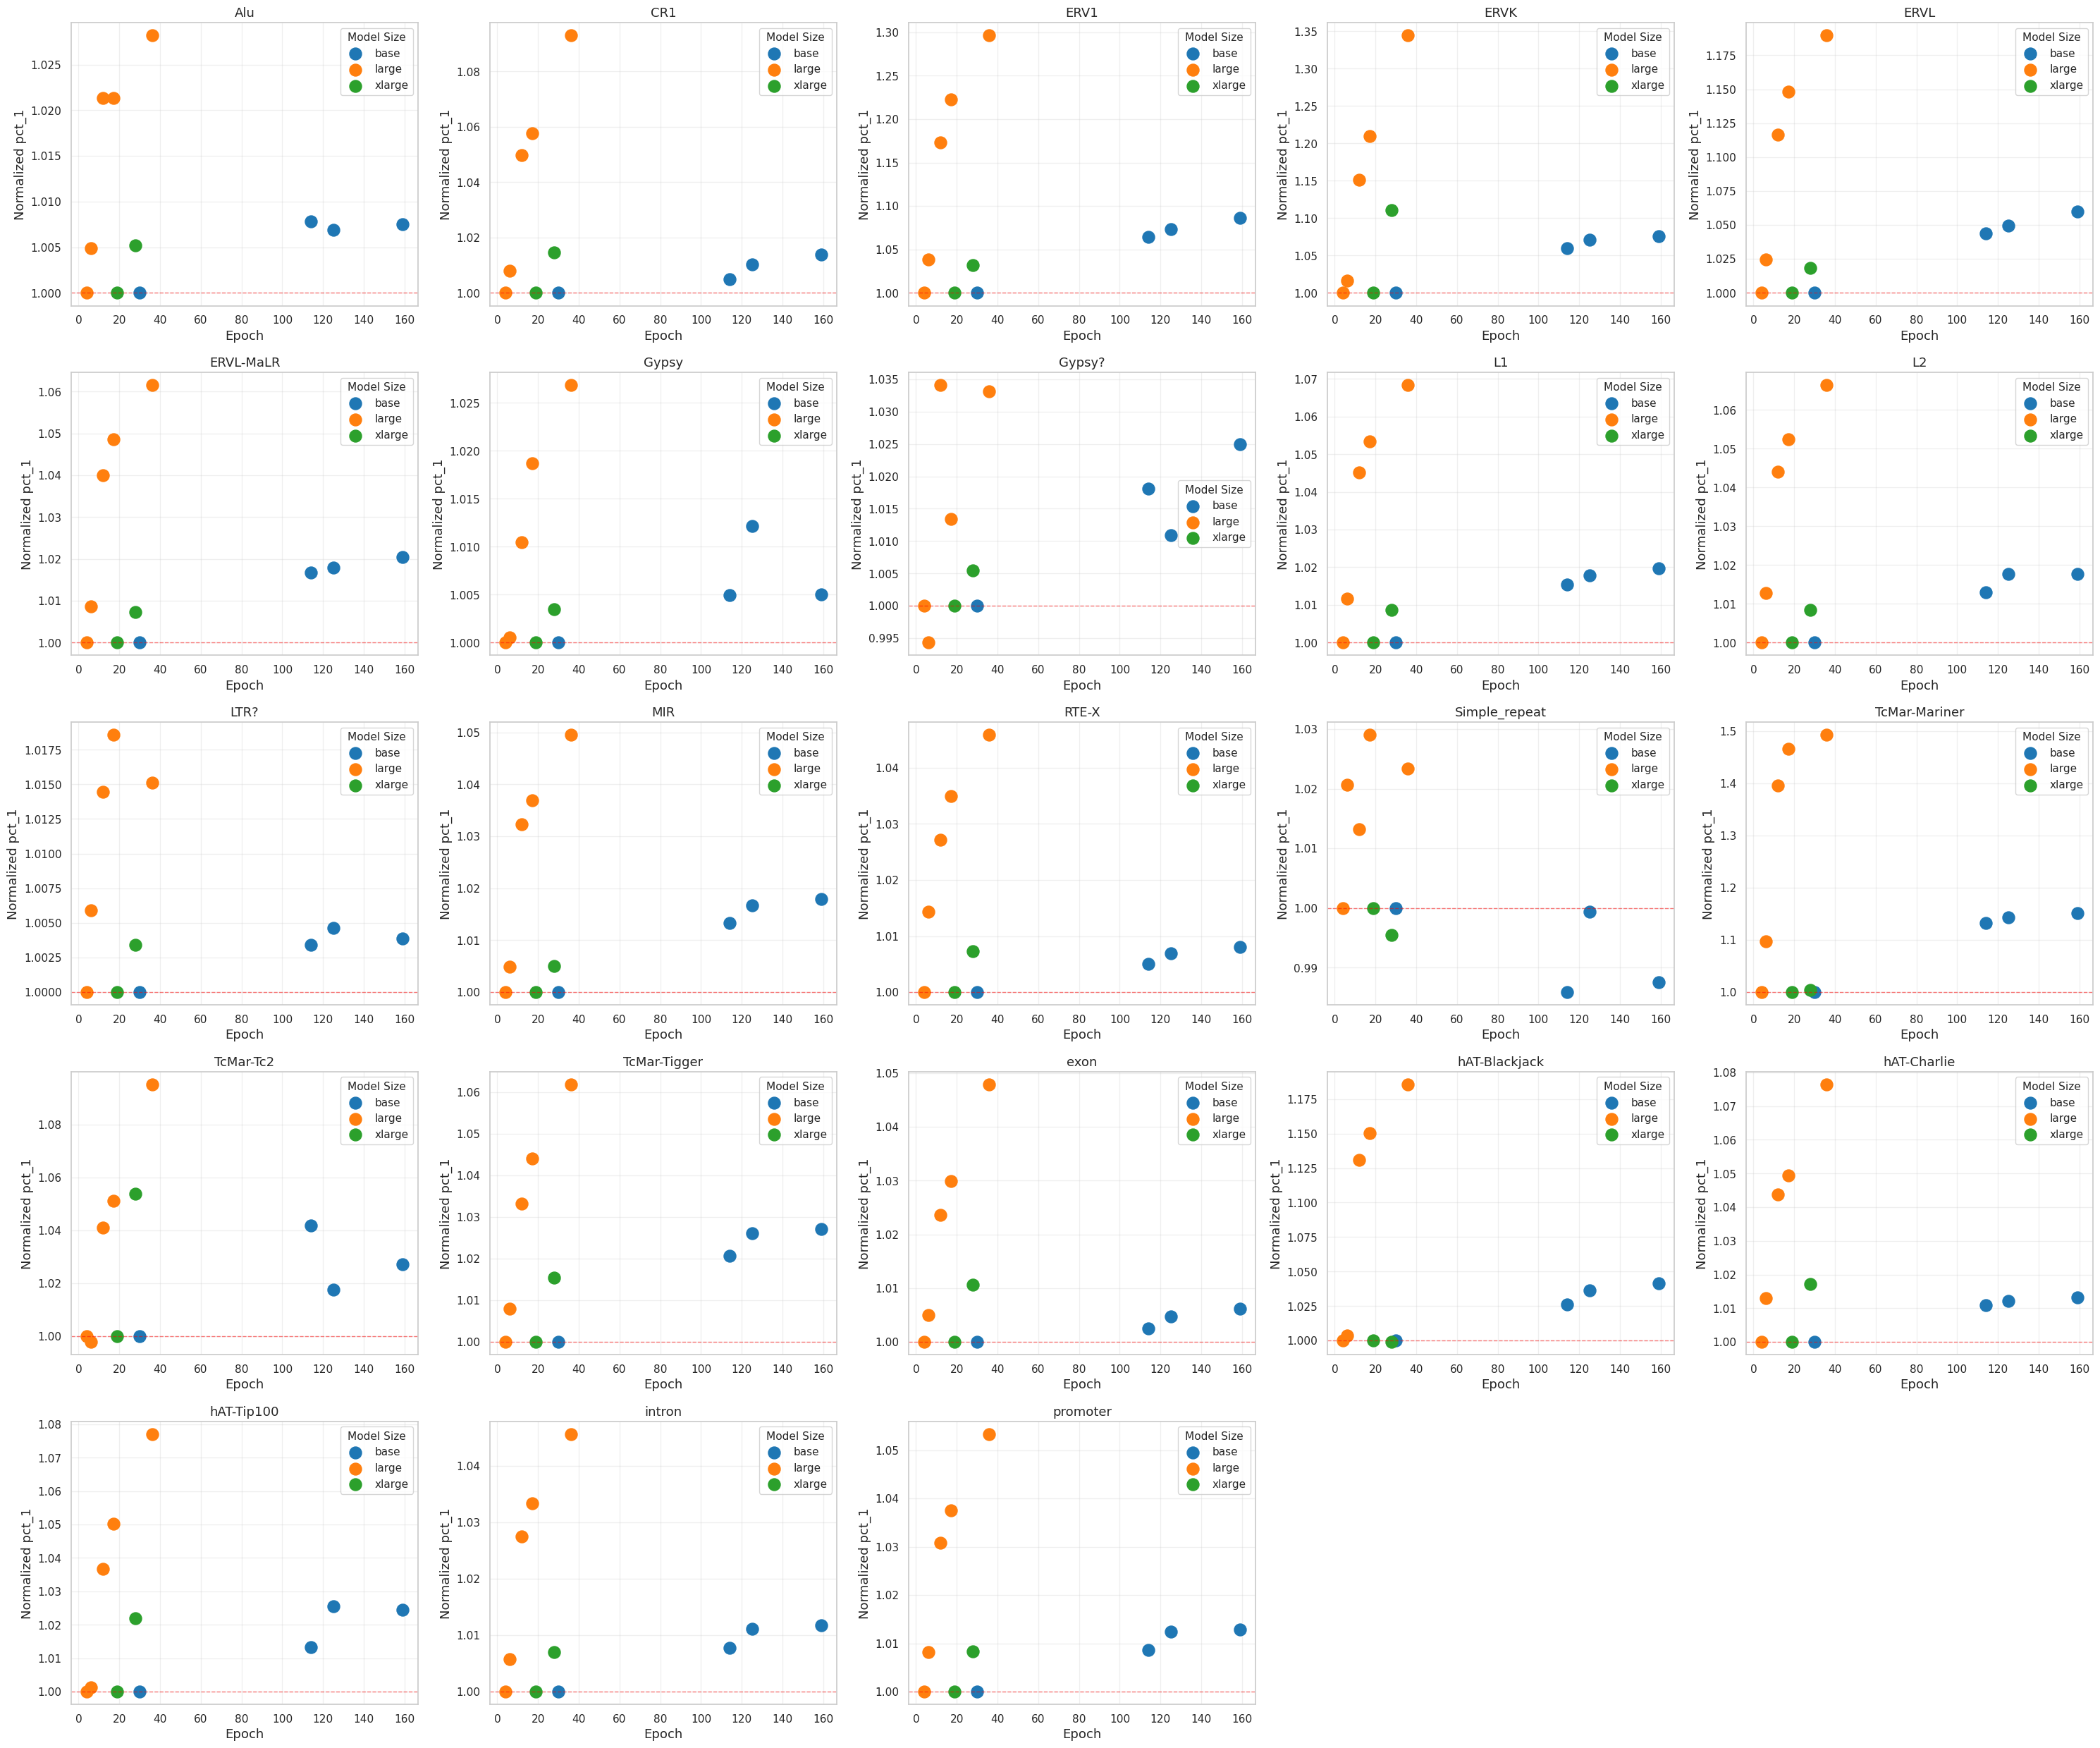

In [7]:
# Filter to only moderngena models
modgena_data = data[data["model_name"].str.contains("modgena", case=False, na=False)].copy()

# Extract epoch and model size from model_name (format: modgena_MODELSIZE_epN_baM)
def extract_epoch(model_name):
    """Extract epoch number from model_name like modgena-base-ep30-ba90700"""
    try:
        # Find pattern: -ep followed by digits
        import re
        match = re.search(r'-ep(\d+)-', model_name)
        if match:
            return int(match.group(1))
    except:
        pass
    return None

def extract_model_size(model_name):
    """Extract model size from model_name like modgena-base-ep30-ba90700"""
    try:
        # Extract part between modgena- and -ep
        import re
        match = re.search(r'modgena-([^-]+)-ep', model_name)
        if match:
            return match.group(1)
    except:
        pass
    return None

modgena_data["epoch"] = modgena_data["model_name"].apply(extract_epoch)
modgena_data["model_size"] = modgena_data["model_name"].apply(extract_model_size)

# Remove rows where we couldn't extract epoch or model_size
modgena_data = modgena_data.dropna(subset=["epoch", "model_size"])

# Get unique feature classes
feature_classes = sorted(modgena_data["feature_class"].unique())
n_features = len(feature_classes)

# Normalize values: for each feature and model_size combination, set minimal epoch value as 1
normalized_data = []
for feature in feature_classes:
    feature_data = modgena_data[modgena_data["feature_class"] == feature].copy()
    
    # Normalize separately for each model_size
    feature_data["normalized_pct1"] = np.nan
    for model_size in feature_data["model_size"].unique():
        size_mask = feature_data["model_size"] == model_size
        size_data = feature_data[size_mask].copy()
        
        # Find minimum epoch value for this feature and model_size
        min_epoch = size_data["epoch"].min()
        min_epoch_data = size_data[size_data["epoch"] == min_epoch]
        min_pct1 = min_epoch_data["pct_1"].mean()  # Use mean if multiple models at min epoch
        
        # Normalize: set min epoch value to 1, scale others proportionally
        feature_data.loc[size_mask, "normalized_pct1"] = size_data["pct_1"] / min_pct1
    
    normalized_data.append(feature_data)

normalized_data = pd.concat(normalized_data, ignore_index=True)

# Create subplots for each feature
sns.set_context("notebook", font_scale=1.13)
sns.set_style("whitegrid")

# Calculate grid dimensions (try to make it roughly square)
n_cols = int(np.ceil(np.sqrt(n_features)))
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
if n_features == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, feature in enumerate(feature_classes):
    feature_data = normalized_data[normalized_data["feature_class"] == feature]
    
    ax = axes[idx]
    
    # Create scatterplot
    for model_size in sorted(feature_data["model_size"].unique()):
        size_data = feature_data[feature_data["model_size"] == model_size]
        # Use a color palette with higher contrast, e.g., tab10
        palette = plt.get_cmap("tab10")
        color_index = list(sorted(feature_data["model_size"].unique())).index(model_size) % 5  # max 5 distinct colors
        ax.scatter(
            size_data["epoch"],
            size_data["normalized_pct1"],
            label=model_size,
            alpha=1,
            s=150,
            color=palette(color_index)
        )
    
    ax.set_xlabel("Epoch", fontsize=13)
    ax.set_ylabel("Normalized pct_1", fontsize=13)
    ax.set_title(feature, fontsize=13)
    ax.tick_params(axis='both', labelsize=11)
    ax.legend(title="Model Size", fontsize=11, title_fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, linewidth=1)  # Reference line at 1.0

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_path, "MLM_acc_by_pretrain_epoch_normalized.png"), dpi=300, bbox_inches='tight')
# plt.close(fig)
